# HUTrackDB — Exploratory Data Analysis & Validation

Opens the built geodatabase and works through, in order:

1. **Load** the tables and the build provenance
2. **Structural checks** — keys, referential integrity, sentinels, value domains
3. **Coverage** — what exists in which era, and why that matters
4. **Intensity** distributions
5. **Landfalls nationally by year**
6. **Landfalls by state** (small multiples)
7. **Detection provenance** — native vs inferred, and the 1971–1990 gap
8. **Timing** — exact vs 6-hourly intensity at landfall
9. **Distance to coast** and near-misses
10. **Geography** — where landfalls happen

> **Runs from a fresh clone.** Everything below reads the committed
> `data/processed/parquet/` tables (~4.9 MB) plus a small committed basemap —
> no download and no build step required. Rebuilding from source is optional:
>
> ```
> python scripts/fetch_sources.py && python -m hutrackdb build
> ```
>
> That regenerates the same tables along with the GeoPackage and SQLite builds,
> which carry identical content but are too large to keep in version control.

Every check prints an explicit **PASS / FAIL**, and every figure is accompanied by
the table it was drawn from, so no value is reachable only through a picture.

## 0. Setup

In [1]:
# Standard scientific stack. geopandas is only needed for the geometry-bearing
# layers; every non-spatial table is read from Parquet, which is much faster.
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# geopandas warns on any operation in a geographic CRS. The pipeline uses
# geodesic maths for distances and projects deliberately where it matters,
# so the warning is noise here.
warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Resolve the project root whether the notebook is run from notebooks/ or repo root.
ROOT = Path.cwd()
if not (ROOT / "data" / "processed" / "parquet").exists():
    ROOT = ROOT.parent
PARQUET = ROOT / "data" / "processed" / "parquet"
BASEMAP = ROOT / "data" / "reference" / "basemap_na_coast.parquet"

# This notebook reads only committed (Geo)Parquet, so it runs from a fresh
# clone with no build step. The GeoPackage and SQLite builds contain the same
# tables and are equally usable, but they are large binaries kept out of
# version control.
if not PARQUET.exists():
    raise FileNotFoundError(
        f"{PARQUET} not found — run `python -m hutrackdb build` first."
    )

size_mb = sum(f.stat().st_size for f in PARQUET.glob("*.parquet")) / 1e6
print("project root :", ROOT)
print("parquet dir  :", PARQUET.relative_to(ROOT), f"({size_mb:.1f} MB)")

project root : /private/tmp/claude-501/-Users-ryanvaughn-HUTrackDB/b9b76845-f3d3-4de8-a146-c1c390abd7ae/scratchpad/clonetest
parquet dir  : data/processed/parquet (5.1 MB)


In [2]:
# ---------------------------------------------------------------------------
# House chart style.
#
# Colors come from a validated palette: categorical hues are used in a FIXED
# order (never cycled), sequential encoding is a single hue light->dark, and
# chart chrome (grid, axes, labels) is recessive -- one shade off the surface.
# ---------------------------------------------------------------------------

SURFACE      = "#fcfcfb"   # chart surface
INK          = "#0b0b0b"   # primary text
INK_SECOND   = "#52514e"   # secondary text
INK_MUTED    = "#898781"   # axis + tick labels
GRID         = "#e1e0d9"   # hairline gridline
AXIS         = "#c3c2b7"   # baseline / axis rule

# Categorical slots, in fixed assignment order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES

# Single-hue sequential ramp (light -> dark) for magnitude encoding.
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
            "#256abf", "#184f95", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family":       ["system-ui", "Helvetica Neue", "Helvetica",
                          "Arial", "DejaVu Sans"],
    "font.size":         10,
    "text.color":        INK,
    "axes.labelcolor":   INK_SECOND,
    "axes.edgecolor":    AXIS,
    "axes.linewidth":    0.8,
    "axes.titlesize":    13,
    "axes.titleweight":  "600",
    "axes.titlecolor":   INK,
    "axes.titlepad":     10,
    "axes.grid":         True,
    "axes.axisbelow":    True,          # grid sits behind the marks
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
    "grid.linestyle":    "-",           # solid hairline; dashed reads as "threshold"
    "xtick.color":       INK_MUTED,
    "ytick.color":       INK_MUTED,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "figure.dpi":        110,
    "savefig.dpi":       110,
})


def tidy(ax, xgrid=False):
    """Strip chart junk: drop the top/right spines and the vertical grid.

    Horizontal gridlines help read a magnitude; vertical ones rarely do.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.grid(xgrid)
    ax.yaxis.grid(True)
    return ax


def caption(fig, text, y=-0.02):
    """Attach a source/caveat note beneath a figure."""
    fig.text(0.0, y, text, ha="left", va="top", fontsize=8.5,
             color=INK_MUTED, wrap=True)

print("style loaded")

style loaded


## 1. Load the geodatabase

In [3]:
# Inventory what the build actually produced, so the notebook documents the
# dataset it opened rather than assuming it.
inventory = pd.DataFrame([
    {"file": f.name, "size_kb": round(f.stat().st_size / 1024)}
    for f in sorted(PARQUET.glob("*.parquet"))
])
display(inventory)

,file,size_kb
0,bypasses.parquet,50
1,landfall_gates.parquet,248
2,landfalls.parquet,596
3,pipeline_metadata.parquet,4
4,storms.parquet,748
5,track_points.parquet,3329


In [4]:
# Every table is GeoParquet: the geometry column travels with the data, so
# `gpd.read_parquet` returns a GeoDataFrame ready to plot. The analysis below
# is columnar, so the tables are read with pandas and the geometry column
# dropped; the map section reads geometry where it needs it.
def load(name):
    frame = pd.read_parquet(PARQUET / f"{name}.parquet")
    return frame.drop(columns="geometry", errors="ignore")

storms      = load("storms")
points      = load("track_points")
landfalls   = load("landfalls")
gates       = load("landfall_gates")
bypasses    = load("bypasses")
metadata    = load("pipeline_metadata")

TABLES = {"storms": storms, "track_points": points, "landfalls": landfalls,
          "landfall_gates": gates, "bypasses": bypasses,
          "pipeline_metadata": metadata}

shape_summary = pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": df.shape[1]}
     for name, df in TABLES.items()]
).set_index("table")
display(shape_summary)

,rows,columns
table,,
storms,3266,19
track_points,87631,33
landfalls,6621,33
landfall_gates,5007,4
bypasses,684,13
pipeline_metadata,19,2


In [5]:
# Build provenance. Every output records the exact sources, checksums, coastline,
# gate set and calibration values that produced it -- so any number in this
# notebook is traceable back to its inputs.
prov = metadata.set_index("key")["value"]
for key in ["schema_version", "generated_at_utc", "coastline_source",
            "gate_set_origin", "gate_count", "parse_warnings"]:
    if key in prov.index:
        print(f"{key:20s} {prov[key]}")

print("\nCalibration parameters in force:")
for key in sorted(k for k in prov.index if k.startswith("calibration.")
                  and not k.endswith((".source", ".status"))):
    name = key.split(".", 1)[1]
    status = prov.get(f"calibration.{name}.status", "?")
    print(f"  {name:28s} = {prov[key]:>8s}   [{status}]")

schema_version       1.0.0
generated_at_utc     2026-08-05T17:35:03+00:00
coastline_source     natural_earth_10m_admin_1
gate_set_origin      generated:uniform@50km
gate_count           5007
parse_warnings       0

Calibration parameters in force:
  bypass_radius_km             =   111.12   [confirmed]
  gate_spacing_km              =     50.0   [confirmed]
  landfall_segment_step_km     =      1.0   [sourced]


## 2. Structural validation

Each check prints PASS or FAIL. These are the properties the schema promises;
if any fail, downstream analysis is unsafe.

In [6]:
# Collect results so the section can end with a single summary table.
results = []

def check(name, condition, detail=""):
    """Record a boolean check and print it immediately."""
    ok = bool(condition)
    results.append({"check": name, "result": "PASS" if ok else "FAIL",
                    "detail": detail})
    print(f"[{'PASS' if ok else 'FAIL'}] {name}" + (f"  — {detail}" if detail else ""))
    return ok

In [7]:
# --- Primary key uniqueness -------------------------------------------------
# Each table's declared grain must actually be unique, or joins silently fan out.
check("storms.storm_id unique",
      storms.storm_id.is_unique,
      f"{storms.storm_id.nunique():,} distinct of {len(storms):,}")

check("track_points (storm_id, point_seq) unique",
      not points.duplicated(["storm_id", "point_seq"]).any())

check("landfall_gates.gate_id unique", gates.gate_id.is_unique)

check("bypasses.storm_id unique", bypasses.storm_id.is_unique)

[PASS] storms.storm_id unique  — 3,266 distinct of 3,266
[PASS] track_points (storm_id, point_seq) unique
[PASS] landfall_gates.gate_id unique
[PASS] bypasses.storm_id unique


True

In [8]:
# --- Referential integrity --------------------------------------------------
# Every child row must point at a parent that exists.
storm_ids = set(storms.storm_id)
gate_ids  = set(gates.gate_id)

check("track_points.storm_id ⊆ storms",
      set(points.storm_id) <= storm_ids)

check("landfalls.storm_id ⊆ storms",
      set(landfalls.storm_id) <= storm_ids)

check("bypasses.storm_id ⊆ storms",
      set(bypasses.storm_id) <= storm_ids)

orphan_gates = set(landfalls.gate_id.dropna()) - gate_ids
check("landfalls.gate_id ⊆ landfall_gates",
      not orphan_gates,
      f"{len(orphan_gates)} orphans")

# A storm that made landfall must not also appear as a near-miss.
overlap = set(bypasses.storm_id) & set(landfalls.loc[landfalls.is_landfall, "storm_id"])
check("bypasses and landfalling storms are disjoint",
      not overlap, f"{len(overlap)} overlapping")

[PASS] track_points.storm_id ⊆ storms
[PASS] landfalls.storm_id ⊆ storms
[PASS] bypasses.storm_id ⊆ storms
[PASS] landfalls.gate_id ⊆ landfall_gates  — 0 orphans
[PASS] bypasses and landfalling storms are disjoint  — 0 overlapping


True

In [9]:
# --- Source fidelity --------------------------------------------------------
# HURDAT2 headers declare how many track rows follow. Parsed counts must match
# exactly; a mismatch means the parser lost or invented a record.
mismatch = storms[storms.n_track_points != storms.n_track_points_declared]
check("parsed track-point counts match HURDAT2 headers",
      mismatch.empty,
      f"{len(mismatch)} storms disagree")

# Aggregates in `storms` must agree with the child table they summarise.
recount = points.groupby("storm_id").size()
joined = storms.set_index("storm_id").n_track_points
check("storms.n_track_points equals actual track_points rows",
      recount.reindex(joined.index).fillna(0).astype(int).equals(joined))

[PASS] parsed track-point counts match HURDAT2 headers  — 0 storms disagree
[PASS] storms.n_track_points equals actual track_points rows


True

In [10]:
# --- Missing-data sentinels -------------------------------------------------
# HURDAT2 encodes missing values as -999 (and -99 for the 1967 depressions).
# The parser converts these to NULL; if any survive as numbers, every mean and
# sum computed downstream would be silently wrong.
#
# Scope matters here. The scan must cover only the MEASUREMENT fields, not the
# coordinates: -99.0 is a perfectly valid longitude (99°W, central Texas), and
# HURDAT2 cannot express a sentinel in a coordinate field anyway because those
# are written with a hemisphere letter ("99.0W"). Scanning every numeric column
# would raise a false alarm on 62 legitimate positions.
SENTINEL_FIELDS = [
    "max_wind_kt", "min_pressure_mb", "radius_max_wind_nm",
    *[f"r{s}_{q}_nm" for s in (34, 50, 64) for q in ("ne", "se", "sw", "nw")],
]
sentinels = int(((points[SENTINEL_FIELDS] == -999) |
                 (points[SENTINEL_FIELDS] == -99)).sum().sum())
check("no -999 / -99 sentinels survive in the measurement fields",
      sentinels == 0, f"{sentinels} found across {len(SENTINEL_FIELDS)} fields")

# Justify excluding the coordinate columns above -- structurally, not by
# assuming a plausible latitude band. The parser requires every coordinate to
# match <digits>[.<digits>]<hemisphere letter> ("29.1N", "90.2W"); "-999"
# cannot be written in that grammar, so a sentinel can never reach these
# columns. A malformed coordinate raises at parse time rather than passing
# through. The valid-range checks below are what confirm it held.
neg99 = points[points.longitude == -99]
check("coordinate columns cannot carry sentinels (parser grammar)",
      points.latitude.between(-90, 90).all()
      and points.longitude.between(-180, 180).all(),
      f"{len(neg99)} rows legitimately sit at 99°W "
      f"({neg99.basin.value_counts().to_dict()}) — real positions, not sentinels")

# The distance-to-coast field is promised for EVERY track point.
missing_dist = int(points.min_distance_to_coast_km.isna().sum())
check("min_distance_to_coast_km populated for every track point",
      missing_dist == 0,
      f"{len(points) - missing_dist:,} / {len(points):,} populated")

[PASS] no -999 / -99 sentinels survive in the measurement fields  — 0 found across 15 fields
[PASS] coordinate columns cannot carry sentinels (parser grammar)  — 62 rows legitimately sit at 99°W ({'EP': 35, 'AL': 27}) — real positions, not sentinels
[PASS] min_distance_to_coast_km populated for every track point  — 87,631 / 87,631 populated


True

In [11]:
# --- Value domains ----------------------------------------------------------
# Categorical columns must contain only codes the HURDAT2 spec defines.
VALID_STATUS = {"TD","TS","HU","EX","SD","SS","LO","WV","DB"}
VALID_RECID  = {"C","G","I","L","P","R","S","T","W"}
VALID_SS     = {"UNK","TD","TS","1","2","3","4","5"}

check("status codes are spec-valid",
      set(points.status.unique()) <= VALID_STATUS,
      f"{sorted(set(points.status.unique()) - VALID_STATUS) or 'none unexpected'}")

check("record identifiers are spec-valid",
      set(points.record_identifier.dropna().unique()) <= VALID_RECID)

check("Saffir-Simpson labels are valid",
      set(points.ss_category.unique()) <= VALID_SS)

# Coordinates must be on the globe; longitudes are normalised to [-180, 180]
# so that Pacific tracks crossing the antimeridian stay contiguous.
check("latitudes within [-90, 90]",
      points.latitude.between(-90, 90).all())
check("longitudes within [-180, 180]",
      points.longitude.between(-180, 180).all())

[PASS] status codes are spec-valid  — none unexpected
[PASS] record identifiers are spec-valid
[PASS] Saffir-Simpson labels are valid
[PASS] latitudes within [-90, 90]
[PASS] longitudes within [-180, 180]


True

In [12]:
# --- Physical plausibility --------------------------------------------------
# Not schema constraints, but ranges outside these would indicate a unit or
# parsing error rather than a real storm.
w = points.max_wind_kt.dropna()
p = points.min_pressure_mb.dropna()

check("max_wind_kt within a physically plausible 0–200 kt",
      w.between(0, 200).all(),
      f"observed {w.min():.0f}–{w.max():.0f} kt")

check("min_pressure_mb within a plausible 850–1050 mb",
      p.between(850, 1050).all(),
      f"observed {p.min():.0f}–{p.max():.0f} mb")

# Saffir-Simpson is derived from wind, so the two must never disagree.
hu = points[points.ss_category.isin(["1","2","3","4","5"])]
check("every Saffir-Simpson category ≥1 has wind ≥ 64 kt",
      (hu.max_wind_kt >= 64).all())

[PASS] max_wind_kt within a physically plausible 0–200 kt  — observed 10–185 kt
[PASS] min_pressure_mb within a plausible 850–1050 mb  — observed 872–1024 mb
[PASS] every Saffir-Simpson category ≥1 has wind ≥ 64 kt


True

In [13]:
# --- Landfall-table invariants ----------------------------------------------
# `is_landfall` separates countable landfalls from overland re-entries.
# A native HURDAT2 "L" flag is authoritative and must never be demoted.
native = landfalls[landfalls.detection_method.isin(["native", "native_confirmed"])]
check("no native-flagged landfall was demoted to a re-entry",
      native.is_landfall.all(),
      f"{len(native):,} native-flagged rows")

check("re-entries are only ever inferred",
      (~landfalls.loc[~landfalls.is_landfall, "detection_method"]
       .isin(["native", "native_confirmed"])).all())

# Landfall sequence numbers must start at 1 and be contiguous per storm.
seq = (landfalls[landfalls.is_landfall]
       .groupby("storm_id").landfall_seq
       .agg(lambda s: sorted(s.unique()) == list(range(1, s.nunique() + 1))))
check("landfall_seq is 1..N contiguous within each storm", seq.all(),
      f"{(~seq).sum()} storms with gaps")

# Every US landfall must carry a state, or the geographic rollups are incomplete.
us_missing = landfalls[landfalls.is_us_landfall & landfalls.landfall_admin1.isna()]
check("every US landfall has a state attributed", us_missing.empty,
      f"{len(us_missing)} missing")

[PASS] no native-flagged landfall was demoted to a re-entry  — 1,310 native-flagged rows
[PASS] re-entries are only ever inferred
[PASS] landfall_seq is 1..N contiguous within each storm  — 0 storms with gaps
[PASS] every US landfall has a state attributed  — 0 missing


True

In [14]:
# Summary of every check above.
summary = pd.DataFrame(results)
n_fail = (summary.result == "FAIL").sum()
print(f"{len(summary)} checks run — {len(summary) - n_fail} passed, {n_fail} failed\n")
display(summary.style.map(
    lambda v: f"color: {'#0ca30c' if v == 'PASS' else '#d03b3b'}; font-weight: 600",
    subset=["result"]))

26 checks run — 26 passed, 0 failed



,check,result,detail
0,storms.storm_id unique,PASS,"3,266 distinct of 3,266"
1,"track_points (storm_id, point_seq) unique",PASS,
2,landfall_gates.gate_id unique,PASS,
3,bypasses.storm_id unique,PASS,
4,track_points.storm_id ⊆ storms,PASS,
5,landfalls.storm_id ⊆ storms,PASS,
6,bypasses.storm_id ⊆ storms,PASS,
7,landfalls.gate_id ⊆ landfall_gates,PASS,0 orphans
8,bypasses and landfalling storms are disjoint,PASS,0 overlapping
9,parsed track-point counts match HURDAT2 headers,PASS,0 storms disagree


## 3. Temporal coverage

HURDAT2 is not uniform across its 175 years. Knowing *when* a field starts
existing is a precondition for any trend claim.

basin,AL,CP,EP
season,,,
2018,16,1,25
2019,20,1,20
2020,31,0,21
2021,21,0,19
2022,16,0,19
2023,21,0,20
2024,18,1,14
2025,13,2,18


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


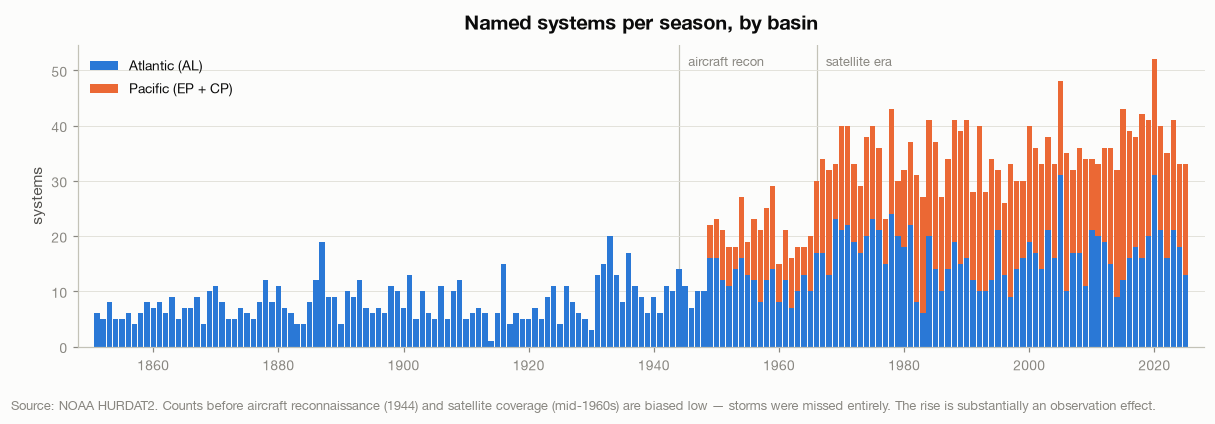

In [15]:
# Storms per season, split by basin. The Pacific record begins in 1949; the
# Atlantic in 1851.
per_season = (storms.groupby(["season", "basin"]).size()
              .unstack(fill_value=0).sort_index())
display(per_season.tail(8))

fig, ax = plt.subplots(figsize=(11, 3.6))

# Atlantic and Pacific are stacked: they partition the same total, so the
# stack height is the meaningful "storms this season" number.
ax.bar(per_season.index, per_season.get("AL", 0),
       width=0.85, color=BLUE, label="Atlantic (AL)", linewidth=0)
pacific = per_season.get("EP", 0) + per_season.get("CP", 0)
ax.bar(per_season.index, pacific, bottom=per_season.get("AL", 0),
       width=0.85, color=ORANGE, label="Pacific (EP + CP)", linewidth=0)

ax.set_title("Named systems per season, by basin")
ax.set_ylabel("systems")
ax.set_xlim(1848, 2028)
ax.legend(loc="upper left")
tidy(ax)

# The two regime shifts that govern how these counts should be read.
for year, label in [(1944, "aircraft recon"), (1966, "satellite era")]:
    ax.axvline(year, color=AXIS, linewidth=0.8, zorder=0)
    ax.text(year + 1.5, ax.get_ylim()[1] * 0.93, label,
            fontsize=8.5, color=INK_MUTED)

caption(fig, "Source: NOAA HURDAT2. Counts before aircraft reconnaissance (1944) and "
             "satellite coverage (mid-1960s) are biased low — storms were missed "
             "entirely. The rise is substantially an observation effect.")
plt.tight_layout()
plt.show()

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


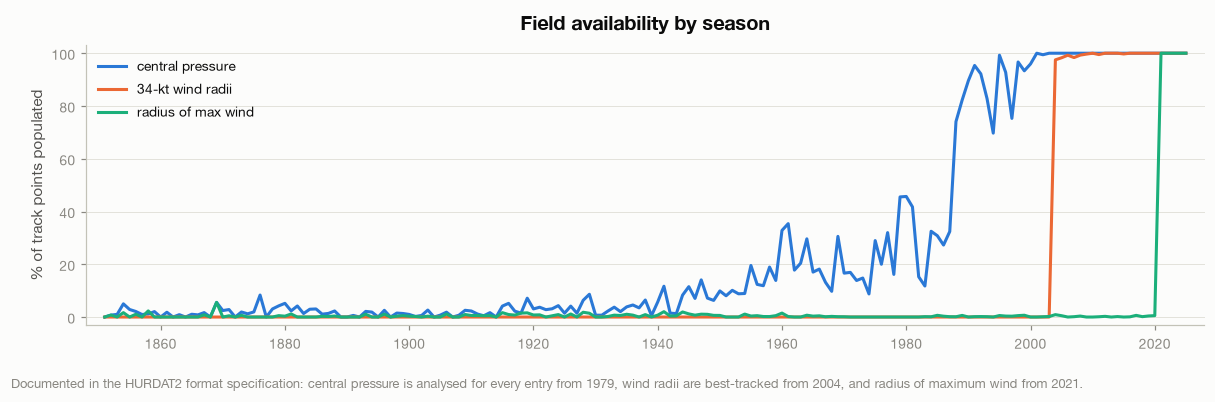

In [16]:
# When does each field actually start? Anything computed on a field before its
# start year is computed on nulls.
availability = pd.DataFrame({
    "central pressure": points.groupby("season").min_pressure_mb.apply(lambda s: s.notna().mean()),
    "34-kt wind radii": points.groupby("season").r34_ne_nm.apply(lambda s: s.notna().mean()),
    "radius of max wind": points.groupby("season").radius_max_wind_nm.apply(lambda s: s.notna().mean()),
})

fig, ax = plt.subplots(figsize=(11, 3.4))
for (name, series), color in zip(availability.items(), [BLUE, ORANGE, AQUA]):
    ax.plot(series.index, series.values * 100, color=color, linewidth=2, label=name)

ax.set_title("Field availability by season")
ax.set_ylabel("% of track points populated")
ax.set_ylim(-3, 103)
ax.set_xlim(1848, 2028)
ax.legend(loc="upper left")
tidy(ax)

caption(fig, "Documented in the HURDAT2 format specification: central pressure is "
             "analysed for every entry from 1979, wind radii are best-tracked from "
             "2004, and radius of maximum wind from 2021.")
plt.tight_layout()
plt.show()

## 4. Intensity distributions

ss_category,UNK,TD,TS,1,2,3,4,5
track_points,57,24702,38379,13374,5635,3224,1974,286


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


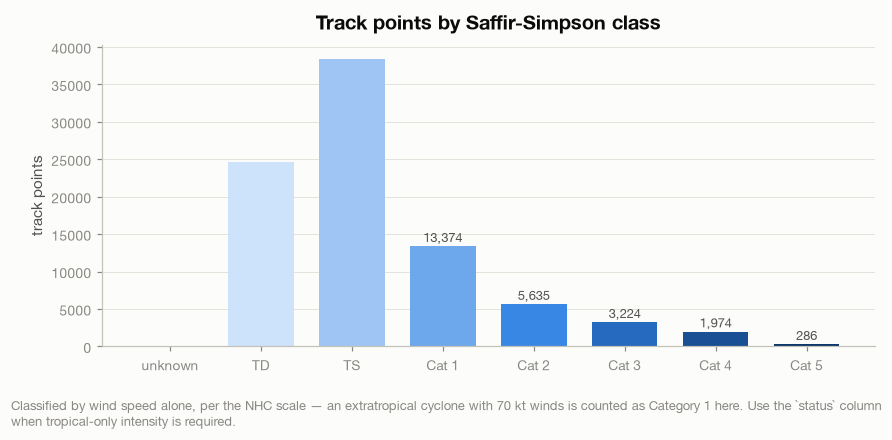

In [17]:
# Distribution of Saffir-Simpson class across all track points.
order = ["UNK", "TD", "TS", "1", "2", "3", "4", "5"]
counts = points.ss_category.value_counts().reindex(order).fillna(0).astype(int)
display(counts.rename("track_points").to_frame().T)

fig, ax = plt.subplots(figsize=(8, 3.6))

# Ordered intensity classes, so a single-hue ordinal ramp is appropriate here:
# the darkening encodes the ordering, which is real information.
ramp = ["#d8d7d2"] + [SEQ_BLUE[i] for i in [0, 1, 2, 3, 4, 5, 6]]
bars = ax.bar(range(len(order)), counts.values, color=ramp, width=0.72, linewidth=0)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(["unknown", "TD", "TS", "Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"])
ax.set_title("Track points by Saffir-Simpson class")
ax.set_ylabel("track points")
tidy(ax)

# Label only the hurricane-strength bars — a number on every bar is noise.
for i, (bar, value) in enumerate(zip(bars, counts.values)):
    if order[i] in ("1", "2", "3", "4", "5"):
        ax.text(bar.get_x() + bar.get_width() / 2, value + counts.max() * 0.015,
                f"{value:,}", ha="center", fontsize=8.5, color=INK_SECOND)

caption(fig, "Classified by wind speed alone, per the NHC scale — an extratropical "
             "cyclone with 70 kt winds is counted as Category 1 here. Use the "
             "`status` column when tropical-only intensity is required.")
plt.tight_layout()
plt.show()

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


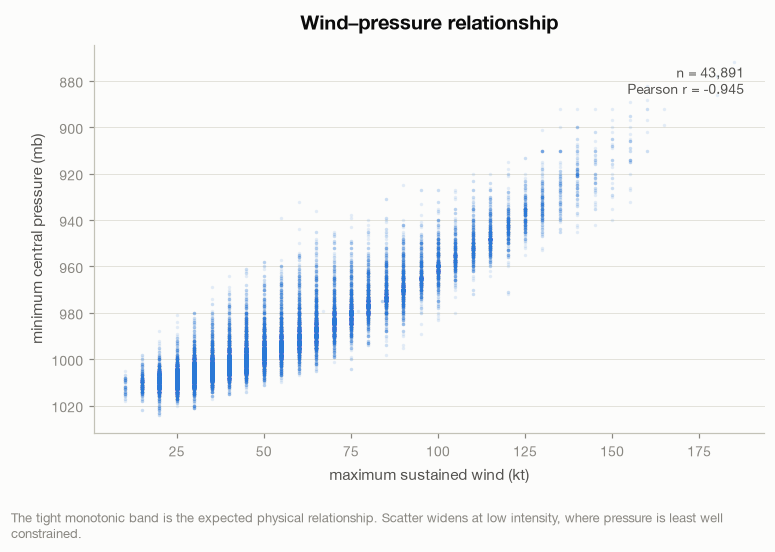

In [18]:
# Wind-pressure relationship. These are physically coupled, so the scatter is a
# strong check that neither field was mis-parsed or unit-shifted.
wp = points[["max_wind_kt", "min_pressure_mb", "season"]].dropna()

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(wp.max_wind_kt, wp.min_pressure_mb,
           s=5, color=BLUE, alpha=0.12, linewidth=0)

ax.set_title("Wind–pressure relationship")
ax.set_xlabel("maximum sustained wind (kt)")
ax.set_ylabel("minimum central pressure (mb)")
ax.invert_yaxis()          # lower pressure = stronger storm, so it reads upward
tidy(ax)

r = wp.max_wind_kt.corr(wp.min_pressure_mb)
ax.text(0.97, 0.95, f"n = {len(wp):,}\nPearson r = {r:.3f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color=INK_SECOND)

caption(fig, "The tight monotonic band is the expected physical relationship. "
             "Scatter widens at low intensity, where pressure is least well constrained.")
plt.tight_layout()
plt.show()

## 5. Landfalls nationally, by year

The headline series. Scope is fixed explicitly so the number is unambiguous:
**countable landfalls** (`is_landfall`), in the **United States**, restricted to
**continental** coastal states.

In [19]:
# Continental US coastal states. Hawaii, Alaska, Puerto Rico and the Virgin
# Islands are US landfalls but are NOT continental, so they are excluded here
# and reported separately -- `is_us_landfall` alone would silently include them.
CONUS_STATES = [
    "Texas", "Louisiana", "Mississippi", "Alabama", "Florida", "Georgia",
    "South Carolina", "North Carolina", "Virginia", "Maryland", "Delaware",
    "New Jersey", "New York", "Pennsylvania", "Connecticut", "Rhode Island",
    "Massachusetts", "New Hampshire", "Maine",
]

lf = landfalls.merge(storms[["storm_id", "season", "name"]], on="storm_id")

us_all = lf[lf.is_landfall & lf.is_us_landfall]
conus  = us_all[us_all.landfall_admin1.isin(CONUS_STATES)].copy()

print(f"countable US landfalls        : {len(us_all):,}")
print(f"  of which continental (CONUS) : {len(conus):,}")
print(f"  non-continental (HI/AK/PR/VI): {len(us_all) - len(conus):,}")
print(f"distinct storms making a CONUS landfall: {conus.storm_id.nunique():,}")
print(f"seasons covered: {conus.season.min()}–{conus.season.max()}")

countable US landfalls        : 1,568
  of which continental (CONUS) : 1,548
  non-continental (HI/AK/PR/VI): 20
distinct storms making a CONUS landfall: 645
seasons covered: 1851–2025


In [20]:
# Two different questions, so two different series -- kept explicit rather than
# collapsed, because "landfalls" and "storms" are not the same count.
national = pd.DataFrame({
    "landfall_events": conus.groupby("season").size(),
    "distinct_storms": conus.groupby("season").storm_id.nunique(),
}).reindex(range(conus.season.min(), conus.season.max() + 1), fill_value=0)

national["events_10yr_mean"] = (national.landfall_events
                                .rolling(10, center=True, min_periods=6).mean())

# Table view: the figure below is drawn from exactly this.
display(national.tail(12))
print(f"\nmean events/yr: {national.landfall_events.mean():.2f}   "
      f"max: {national.landfall_events.max()} "
      f"({national.landfall_events.idxmax()})   "
      f"seasons with none: {(national.landfall_events == 0).sum()}")

,landfall_events,distinct_storms,events_10yr_mean
season,,,
2014,3,1,7.500000
2015,6,2,7.800000
2016,10,5,9.100000
2017,13,5,10.200000
2018,9,4,10.800000
2019,6,5,10.800000
2020,20,11,11.400000
2021,22,8,10.900000
2022,14,4,11.000000



mean events/yr: 8.85   max: 30 (1999)   seasons with none: 3


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


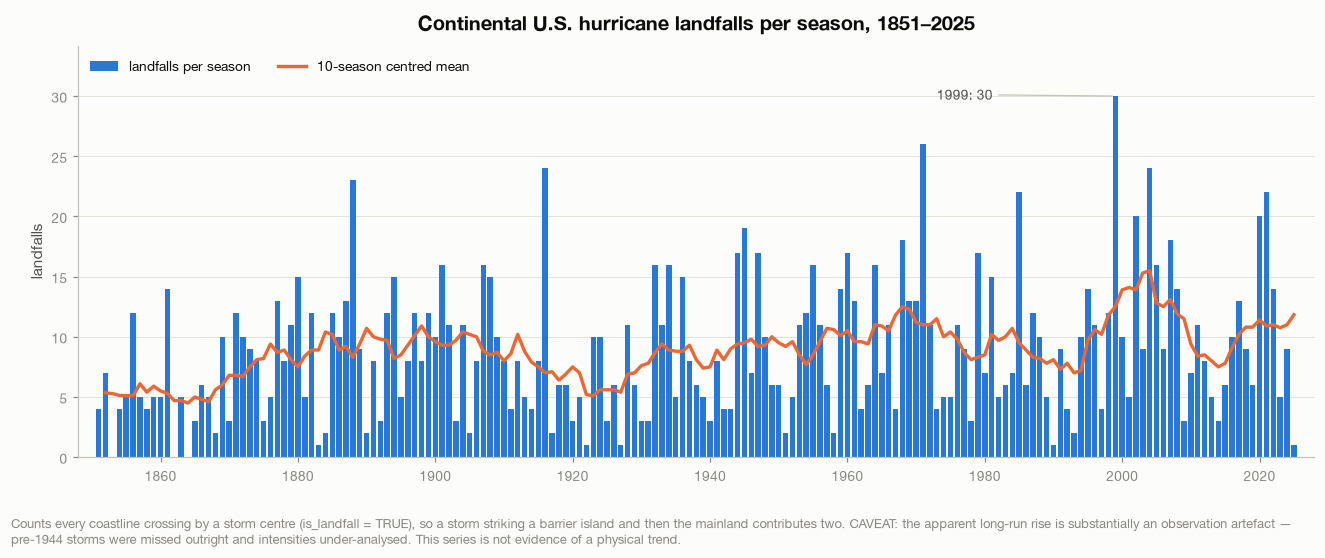

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.6))

# Annual counts as thin bars; the 10-year centred mean rides on the same axis
# (both are counts of the same thing, so a second y-axis would be indefensible).
ax.bar(national.index, national.landfall_events,
       width=0.8, color=BLUE, linewidth=0, label="landfalls per season")
ax.plot(national.index, national.events_10yr_mean,
        color=ORANGE, linewidth=2.2, label="10-season centred mean")

ax.set_title("Continental U.S. hurricane landfalls per season, 1851–2025")
ax.set_ylabel("landfalls")
ax.set_xlim(1848, 2028)
ax.set_ylim(0, national.landfall_events.max() * 1.14)
tidy(ax)

# Order the legend so the primary series reads first; matplotlib collects line
# artists before patches, which would otherwise put the summary line ahead of
# the data it summarises.
handles, labels = ax.get_legend_handles_labels()
order = [labels.index("landfalls per season"), labels.index("10-season centred mean")]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc="upper left", ncols=2)

# Direct-label only the record season -- selective, not one label per bar.
peak_year = int(national.landfall_events.idxmax())
peak_val = int(national.landfall_events.max())
ax.annotate(f"{peak_year}: {peak_val}",
            xy=(peak_year, peak_val), xytext=(peak_year - 26, peak_val * 0.99),
            fontsize=9, color=INK_SECOND,
            arrowprops=dict(arrowstyle="-", color=AXIS, linewidth=0.8))

caption(fig,
    "Counts every coastline crossing by a storm centre (is_landfall = TRUE), so a "
    "storm striking a barrier island and then the mainland contributes two. "
    "CAVEAT: the apparent long-run rise is substantially an observation artefact — "
    "pre-1944 storms were missed outright and intensities under-analysed. "
    "This series is not evidence of a physical trend.", y=-0.03)
plt.tight_layout()
plt.show()

## 6. Landfalls by state — small multiples

One panel per coastal state, on a **shared y-axis** so panels are directly
comparable — that comparability is the entire point of small multiples. Panels
are ordered by total landfalls, so the ranking is readable at a glance.

In [22]:
# Long-form state-by-season matrix, zero-filled so quiet seasons show as gaps
# rather than vanishing from the series.
years = range(conus.season.min(), conus.season.max() + 1)
by_state = (conus.groupby(["landfall_admin1", "season"]).size()
            .unstack(fill_value=0).reindex(columns=years, fill_value=0))

state_totals = by_state.sum(axis=1).sort_values(ascending=False)
by_state = by_state.loc[state_totals.index]

# A 10-season centred mean per state. Annual counts for the smaller states are
# almost all 0 or 1, which on a shared axis renders as sparse single-pixel
# ticks; the smoothed line gives every panel a legible signal at the same
# scale, so the panels stay directly comparable.
by_state_smooth = by_state.T.rolling(10, center=True, min_periods=6).mean().T

display(state_totals.rename("total_landfalls").to_frame().T)
print(f"{len(by_state)} states with at least one recorded landfall")

landfall_admin1,Florida,North Carolina,Louisiana,Texas,New York,Maine,South Carolina,Mississippi,Georgia,Massachusetts,Virginia,Alabama,Connecticut,New Jersey,Maryland,Rhode Island
total_landfalls,512,216,195,175,73,56,56,41,40,39,31,29,25,22,20,18


16 states with at least one recorded landfall


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


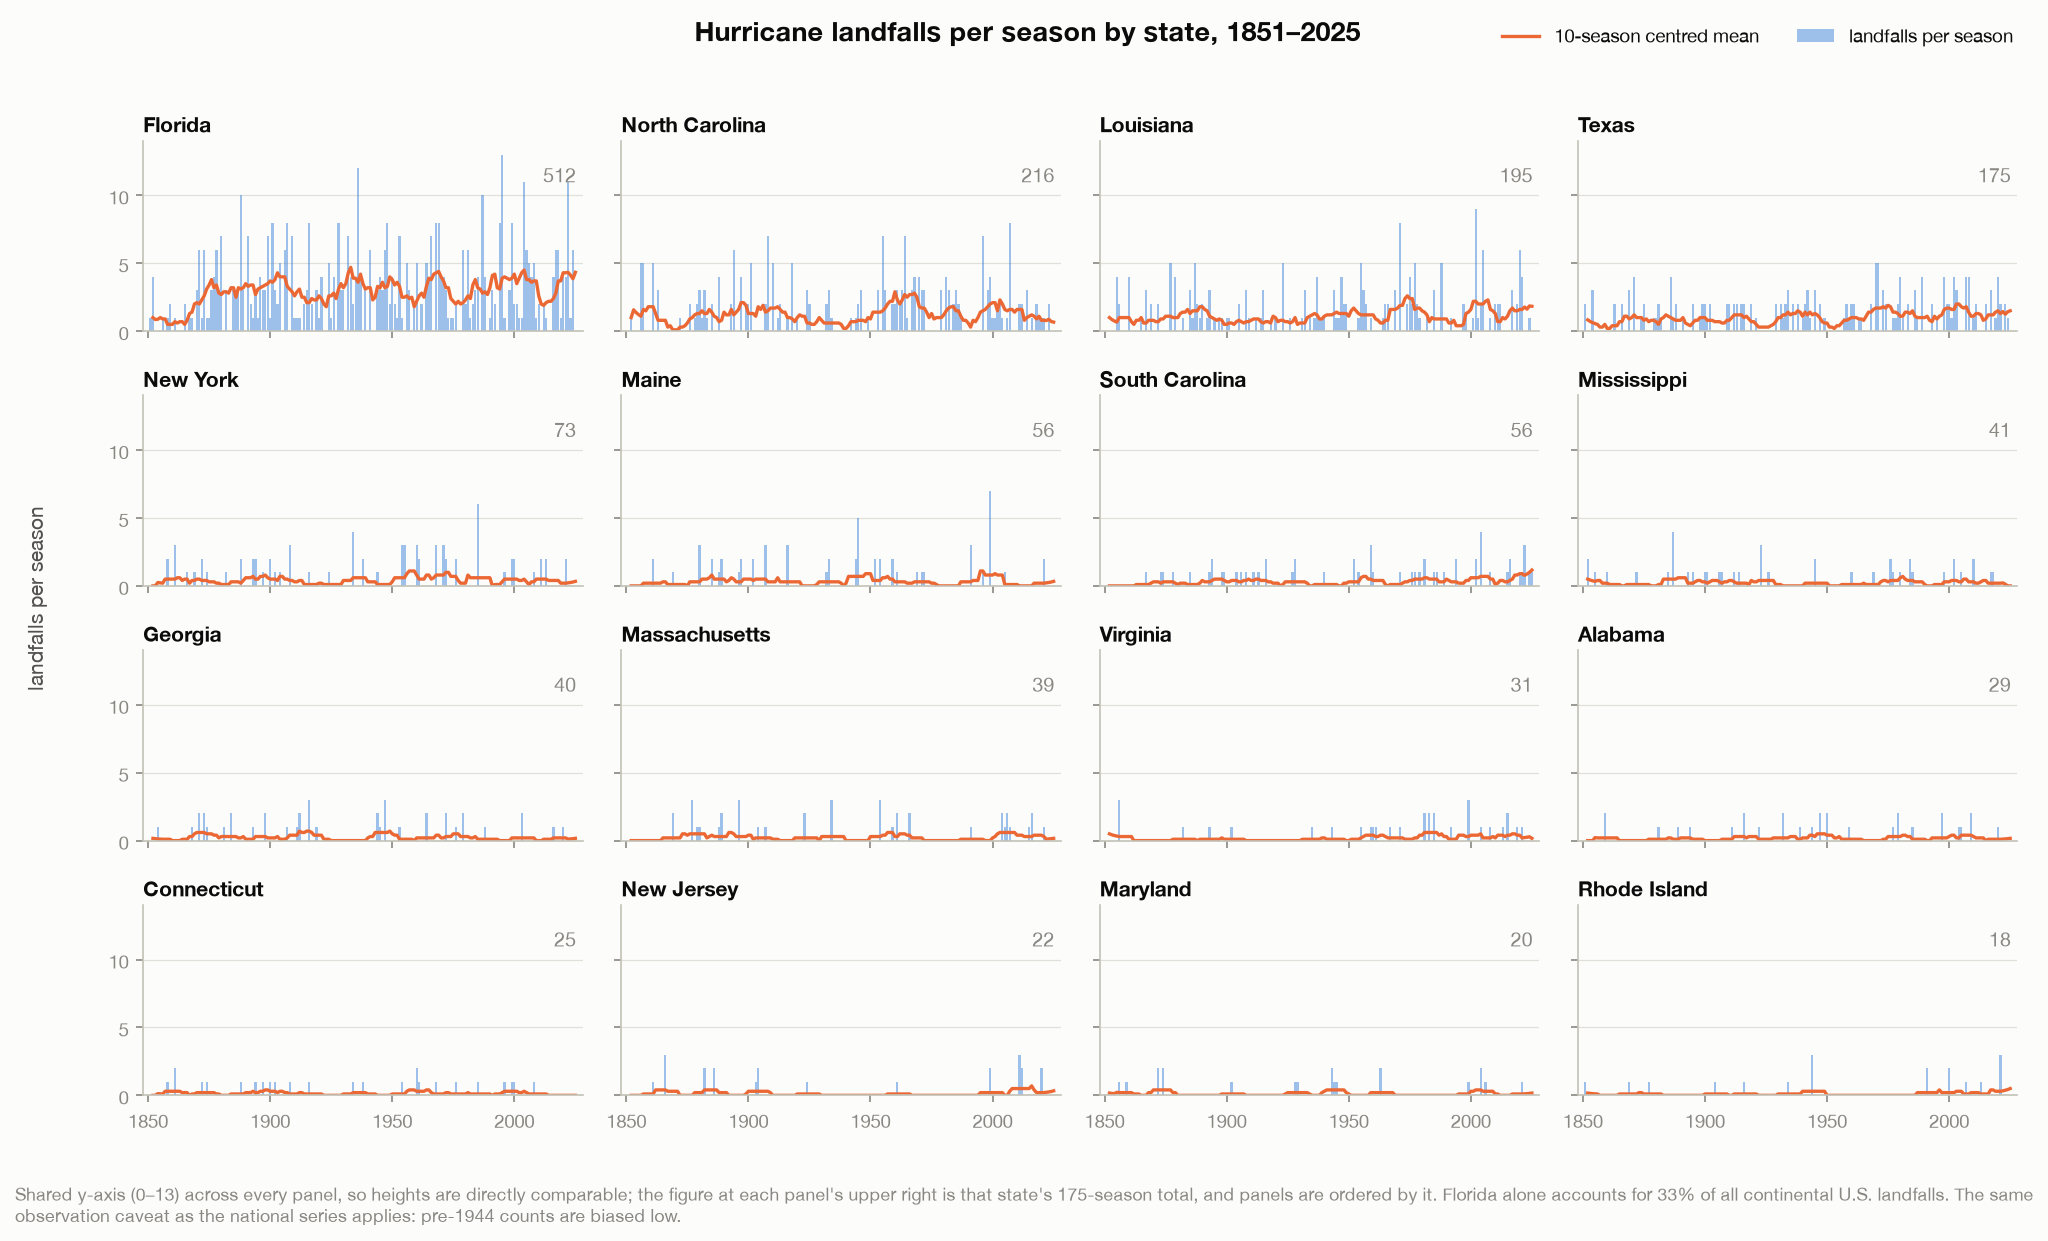

In [23]:
n = len(by_state)
ncols = 4
nrows = int(np.ceil(n / ncols))
ymax = int(by_state.values.max())

# Higher DPI than the notebook default: at 175 seasons across a narrow panel a
# single year is under two pixels, and antialiasing turns isolated tall bars
# into grey smears at the default resolution.
fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 1.95 * nrows),
                         sharex=True, sharey=True, dpi=150)
axes = axes.ravel()

for ax, state in zip(axes, by_state.index):
    annual = by_state.loc[state]
    smooth = by_state_smooth.loc[state]

    # Annual counts recede; the smoothed trend carries the comparison. Bars are
    # width 0.9 rather than 1.0 so adjacent seasons keep a surface gap instead
    # of fusing into a solid block.
    ax.bar(annual.index, annual.values, width=0.9,
           color=BLUE, alpha=0.45, linewidth=0, label="landfalls per season")
    ax.plot(smooth.index, smooth.values,
            color=ORANGE, linewidth=1.6, label="10-season centred mean")

    ax.set_title(state, fontsize=10, loc="left", pad=4)
    # Panel total, so short bars stay quantitatively readable.
    ax.text(0.985, 0.88, f"{int(state_totals[state]):,}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9.5, color=INK_MUTED)

    ax.set_xlim(1848, 2028)
    ax.set_ylim(0, ymax * 1.08)
    ax.set_yticks([0, 5, 10])
    tidy(ax)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

# Blank out unused grid positions rather than leaving empty axes.
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Hurricane landfalls per season by state, 1851–2025",
             fontsize=13, fontweight="600", color=INK, x=0.5, y=0.999)
fig.supylabel("landfalls per season", fontsize=10, color=INK_SECOND, x=0.004)

# One legend for the whole figure -- repeating it in all 16 panels would be noise.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncols=2,
           bbox_to_anchor=(0.995, 1.005), fontsize=9)

caption(fig,
    "Shared y-axis (0–%d) across every panel, so heights are directly comparable; "
    "the figure at each panel's upper right is that state's 175-season total, and "
    "panels are ordered by it. Florida alone accounts for %.0f%% of all continental "
    "U.S. landfalls. The same observation caveat as the national series applies: "
    "pre-1944 counts are biased low." % (ymax, 100 * state_totals.iloc[0] / state_totals.sum()),
    y=0.0)
plt.tight_layout(rect=[0.012, 0.025, 1, 0.982])
plt.show()

## 7. Detection provenance

HURDAT2's native `L` flag is authoritative but incomplete: per the format
specification, continental US landfalls are flagged only for **1851–1970 and
1991 onward**. The inference layer exists to cover **1971–1990**.

decade,1850,1860,1870,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
detection_method,,,,,,,,,,,,,,,,,,
native_confirmed,20,25,39,48,48,48,31,27,44,46,46,47,5,24,40,65,37,41
native,0,0,3,1,3,0,1,0,0,2,1,1,0,0,2,2,3,2
inferred,26,25,40,53,34,54,43,29,44,47,38,61,99,71,55,61,38,28


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


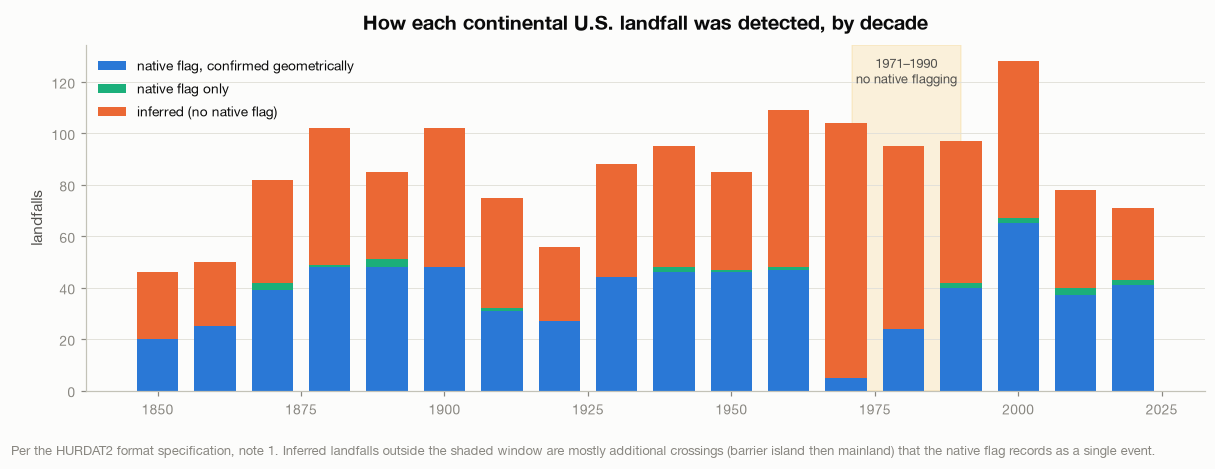

In [24]:
# How each landfall was found, by decade.
prov_decade = (conus.assign(decade=(conus.season // 10) * 10)
               .groupby(["decade", "detection_method"]).size()
               .unstack(fill_value=0))
for col in ["native_confirmed", "native", "inferred"]:
    if col not in prov_decade:
        prov_decade[col] = 0
prov_decade = prov_decade[["native_confirmed", "native", "inferred"]]
display(prov_decade.T)

fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(prov_decade))
for col, color, label in [
    ("native_confirmed", BLUE,   "native flag, confirmed geometrically"),
    ("native",           AQUA,   "native flag only"),
    ("inferred",         ORANGE, "inferred (no native flag)"),
]:
    ax.bar(prov_decade.index, prov_decade[col], bottom=bottom, width=7.2,
           color=color, label=label, linewidth=0)
    bottom += prov_decade[col].values

ax.set_title("How each continental U.S. landfall was detected, by decade")
ax.set_ylabel("landfalls")
ax.legend(loc="upper left")
tidy(ax)

# Mark the documented native-flagging gap this layer exists to fill.
ax.axvspan(1971, 1990, color="#eda100", alpha=0.13, zorder=0)
ax.text(1980.5, ax.get_ylim()[1] * 0.97, "1971–1990\nno native flagging",
        ha="center", va="top", fontsize=8.5, color=INK_SECOND)

caption(fig, "Per the HURDAT2 format specification, note 1. Inferred landfalls "
             "outside the shaded window are mostly additional crossings (barrier "
             "island then mainland) that the native flag records as a single event.")
plt.tight_layout()
plt.show()

## 8. Timing — exact vs 6-hourly intensity

For storms intensifying up to the coast, *which* time is called "landfall"
changes the intensity attributed to it. The schema stores both and privileges
neither.

In [25]:
# Compare intensity at the exact crossing against the preceding synoptic fix.
timing = conus.dropna(subset=["exact_wind_kt", "sixhr_wind_kt"]).copy()
timing["delta_kt"] = timing.exact_wind_kt - timing.sixhr_wind_kt

differ = (timing.delta_kt != 0).sum()
print(f"landfalls with both intensities recorded : {len(timing):,}")
print(f"  where the two differ                    : {differ:,} ({differ/len(timing):.0%})")
print(f"  exact stronger than 6-hourly            : {(timing.delta_kt > 0).sum():,}")
print(f"  exact weaker than 6-hourly              : {(timing.delta_kt < 0).sum():,}")
print(f"  largest intensification into landfall   : +{timing.delta_kt.max():.0f} kt")

display(timing.nlargest(6, "delta_kt")[
    ["name", "season", "landfall_admin1", "sixhr_wind_kt",
     "exact_wind_kt", "delta_kt", "hours_from_6hr_to_landfall"]]
    .reset_index(drop=True))

landfalls with both intensities recorded : 1,530
  where the two differ                    : 563 (37%)
  exact stronger than 6-hourly            : 134
  exact weaker than 6-hourly              : 429
  largest intensification into landfall   : +15 kt


,name,season,landfall_admin1,sixhr_wind_kt,exact_wind_kt,delta_kt,hours_from_6hr_to_landfall
0,UNNAMED,1898,Florida,55,70.0,15.0,4.962121
1,UNNAMED,1898,Florida,55,70.0,15.0,5.533333
2,ANDREW,1992,Florida,130,145.0,15.0,2.666667
3,ANDREW,1992,Florida,130,145.0,15.0,3.210145
4,GORDON,2018,Florida,30,45.0,15.0,5.343750
5,MICHAEL,2018,Florida,125,140.0,15.0,5.419118


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


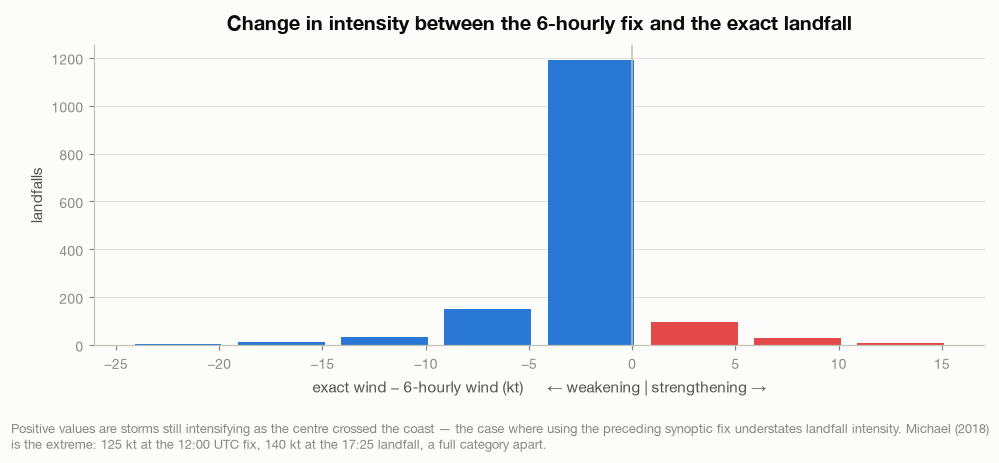

In [26]:
fig, ax = plt.subplots(figsize=(9, 3.8))

# Diverging quantity (strengthening vs weakening about a true zero), so a
# warm/cool pair with a neutral zero is the correct encoding.
bins = np.arange(timing.delta_kt.min() - 2.5, timing.delta_kt.max() + 5, 5)
counts, edges = np.histogram(timing.delta_kt, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
colors = [RED if c > 0 else (BLUE if c < 0 else "#c3c2b7") for c in centers]

ax.bar(centers, counts, width=4.2, color=colors, linewidth=0)
ax.axvline(0, color=AXIS, linewidth=1)

ax.set_title("Change in intensity between the 6-hourly fix and the exact landfall")
ax.set_xlabel("exact wind − 6-hourly wind (kt)      ← weakening | strengthening →")
ax.set_ylabel("landfalls")
tidy(ax)

caption(fig, "Positive values are storms still intensifying as the centre crossed the "
             "coast — the case where using the preceding synoptic fix understates "
             "landfall intensity. Michael (2018) is the extreme: 125 kt at the 12:00 UTC "
             "fix, 140 kt at the 17:25 landfall, a full category apart.")
plt.tight_layout()
plt.show()

## 9. Distance to coast and near-misses

In [27]:
# min_distance_to_coast_km is populated on every track point, so the bypass
# radius shipped with the build is only a label -- any threshold can be applied
# after the fact without re-running the pipeline. Demonstrated here.
closest = points.groupby("storm_id").min_distance_to_coast_km.min()
landfalling = set(landfalls.loc[landfalls.is_landfall, "storm_id"])
near = closest[~closest.index.isin(landfalling)]

thresholds = [50, 111.12, 200, 300, 500]
table = pd.DataFrame({
    "radius_km": thresholds,
    "non_landfalling_storms_within": [int((near <= t).sum()) for t in thresholds],
})
table["pct_of_non_landfalling"] = (100 * table.non_landfalling_storms_within
                                   / len(near)).round(1)
display(table)
print(f"shipped bypass radius = {float(prov['calibration.bypass_radius_km']):.2f} km "
      f"→ {len(bypasses):,} bypass storms in the built table")

,radius_km,non_landfalling_storms_within,pct_of_non_landfalling
0,50.00,315,17.5
1,111.12,684,38.0
2,200.00,986,54.7
3,300.00,1209,67.1
4,500.00,1469,81.5


shipped bypass radius = 111.12 km → 684 bypass storms in the built table


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


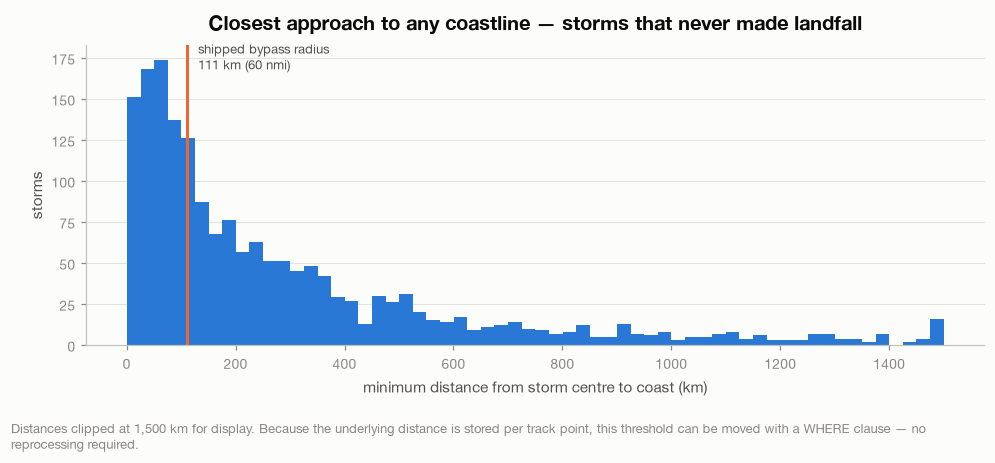

In [28]:
fig, ax = plt.subplots(figsize=(9, 3.8))

ax.hist(near.clip(upper=1500), bins=60, color=BLUE, linewidth=0)
ax.set_title("Closest approach to any coastline — storms that never made landfall")
ax.set_xlabel("minimum distance from storm centre to coast (km)")
ax.set_ylabel("storms")
tidy(ax)

# Mark the shipped radius; it is a labelling choice, not a data boundary.
radius = float(prov["calibration.bypass_radius_km"])
ax.axvline(radius, color=ORANGE, linewidth=2)
ax.text(radius + 20, ax.get_ylim()[1] * 0.92,
        f"shipped bypass radius\n{radius:.0f} km (60 nmi)",
        fontsize=8.5, color=INK_SECOND)

caption(fig, "Distances clipped at 1,500 km for display. Because the underlying "
             "distance is stored per track point, this threshold can be moved with a "
             "WHERE clause — no reprocessing required.")
plt.tight_layout()
plt.show()

## 10. Where landfalls happen

In [29]:
# Landfall positions are plain columns (exact_lon / exact_lat), so the CONUS
# frame already assembled above is all the point data the map needs.
#
# The backdrop comes from a small committed extract of the Natural Earth
# coastline (data/reference/, ~145 KB, built by scripts/make_basemap.py). It is
# clipped and simplified for DISPLAY ONLY -- landfall detection always uses the
# full-precision coastline configured in config/pipeline.yaml, never this file.
coast = gpd.read_parquet(BASEMAP)

print(f"{len(conus):,} continental U.S. landfall points to plot")
print(f"basemap: {len(coast)} display polygons "
      f"({BASEMAP.stat().st_size / 1024:.0f} KB)")

1,548 continental U.S. landfall points to plot
basemap: 102 display polygons (145 KB)


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


...

findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


findfont: Font family 'system-ui' not found.


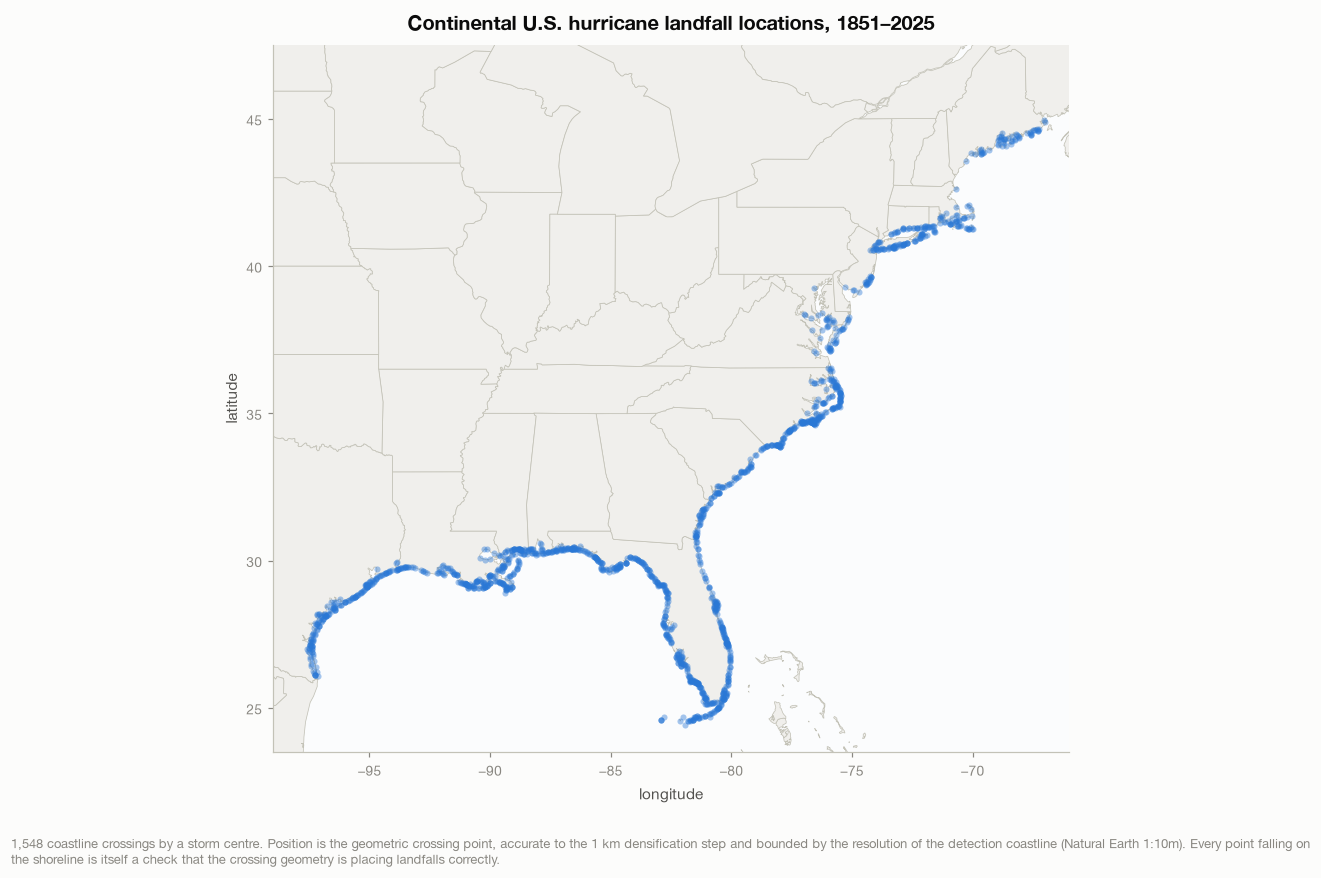

In [30]:
fig, ax = plt.subplots(figsize=(12, 7.5))

# Land as a recessive backdrop; the landfall points are the data.
coast.plot(ax=ax, facecolor="#f0efec", edgecolor=AXIS, linewidth=0.5)

ax.scatter(conus.exact_lon, conus.exact_lat,
           s=16, color=BLUE, alpha=0.42, linewidth=0, zorder=3)

ax.set_xlim(-99, -66)
ax.set_ylim(23.5, 47.5)

# Plotting lon/lat on equal axes stretches the map vertically, because a degree
# of longitude is shorter than a degree of latitude away from the equator.
# Scaling by 1/cos(mid-latitude) restores true local proportions.
ax.set_aspect(1 / np.cos(np.radians(35)))
ax.set_title("Continental U.S. hurricane landfall locations, 1851–2025")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_facecolor("#fbfcfd")     # a hint of water behind the land
ax.grid(False)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

caption(fig, f"{len(conus):,} coastline crossings by a storm centre. Position is the "
             "geometric crossing point, accurate to the 1 km densification step and "
             "bounded by the resolution of the detection coastline (Natural Earth "
             "1:10m). Every point falling on the shoreline is itself a check that the "
             "crossing geometry is placing landfalls correctly.")
plt.tight_layout()
plt.show()

## Summary

**Validation.** All structural checks pass: keys are unique, referential
integrity holds, parsed track-point counts match the HURDAT2 headers exactly,
no missing-data sentinels survive as numbers, every categorical value is
spec-valid, and no native landfall flag was demoted by the inference layer.

**What the data will and will not support.**

- `min_distance_to_coast_km` is populated on all track points, so any coastal
  proximity threshold can be applied after the fact.
- Landfall counts are counts of **crossings**, not storms — a barrier-island
  strike followed by a mainland strike is two rows. Both figures are available.
- Exact and 6-hourly landfall intensities differ for a large share of events;
  which one to use is an analytical choice the schema deliberately leaves open.
- **Long-run landfall trends are not physical.** Pre-1944 counts are biased low
  by missed storms and under-analysed intensities. Any trend claim must be
  restricted to the satellite era or explicitly corrected for detection bias.

**Provenance.** Every figure here traces to `pipeline_metadata`, which records
the source files and checksums, the coastline, the gate set, and each
calibration value with its status and source.